## You know The Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal as mvn

## Loading......

In [2]:
df_train = pd.read_csv("../../dataset/day19/MNIST_train.csv",index_col='index')
df_test = pd.read_csv("../../dataset/day19/MNIST_test.csv",index_col='index')
df_train = df_train.iloc[:,1:]
df_test = df_test.iloc[:,1:]

In [3]:
print(df_train.head())
print(df_test.head())

       labels  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  \
index                                     ...                                 
0           5  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0   
1           0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0   
2           4  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0   
3           1  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0   
4           9  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0   

       780  781  782  783  
index                      
0        0    0    0    0  
1        0    0    0    0  
2        0    0    0    0  
3        0    0    0    0  
4        0    0    0    0  

[5 rows x 785 columns]
       labels  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  \
index                                     ...                                 
0           7  0  0  0  0  0  0  0  0  0  ...    0    0    0    0   

In [4]:
X_train_df = df_train.iloc[:,1:]
y_train_df = df_train.iloc[:,0]
X_test_df = df_test.iloc[:,1:]
y_test_df = df_test.iloc[:,0]

In [5]:
X_train = X_train_df.to_numpy()
y_train = y_train_df.to_numpy()
X_test = X_test_df.to_numpy()
y_test = y_test_df.to_numpy()

### Vizzz

In [9]:
def show_me(X):
    plt.imshow(X.reshape(28,28))

In [11]:
def show_me_mean(X):
    plt.imshow(X.mean(axis=0).reshape(28, 28))

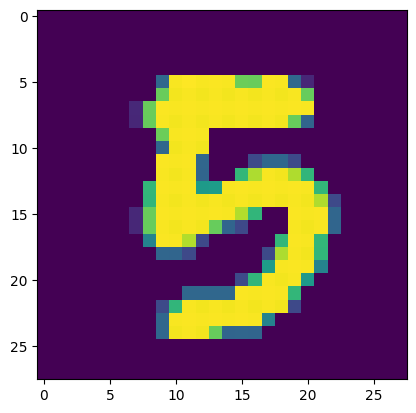

In [10]:
show_me(X_train[244])

In [ ]:
show_me_mean(X_train)

ValueError: cannot reshape array of size 1 into shape (28,28)

### Naive Bayes' Classifier

In [15]:
class GaussNB():

    def fit(self, X, y, epsilon = 1e-3):

        self.likelihood = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            
            X_k = X[y==k]
            self.likelihood[k] = {"mean": X_k.mean(axis=0),"cov":X_k.var(axis=0)+epsilon}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N,len(self.K)))

        for k, l in self.likelihood.items():
            P_hat[:,k] = mvn.logpdf(X,l['mean'],l['cov'])+np.log(self.priors[k])

        return P_hat.argmax(axis=1)


In [16]:
gnb = GaussNB()

In [17]:
gnb.fit(X_train,y_train)

In [19]:
y_hat_train = gnb.predict(X_train)

In [20]:
def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [ ]:
acc_train = accuracy(y_train,y_hat_train)
print(acc_train)

0.5938


In [22]:
y_hat_test = gnb.predict(X_test)
acc_test = accuracy(y_test,y_hat_test)
print(acc_test)

0.5878


In [ ]:
def confusion_matrix(y,y_hat):
    plt.figure(figsize=(10,7))
    y_actu = pd.Series(y, name='Actual')
    y_pred = pd.Series(y_hat, name='Predicted')
    cm = pd.crosstab(y_actu, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt="d")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

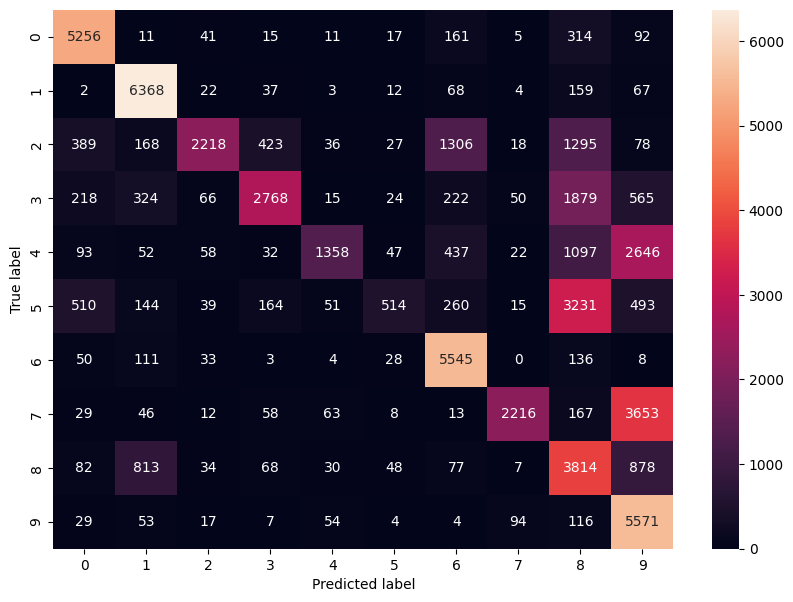

In [ ]:
confusion_matrix(y_train,y_hat_train)

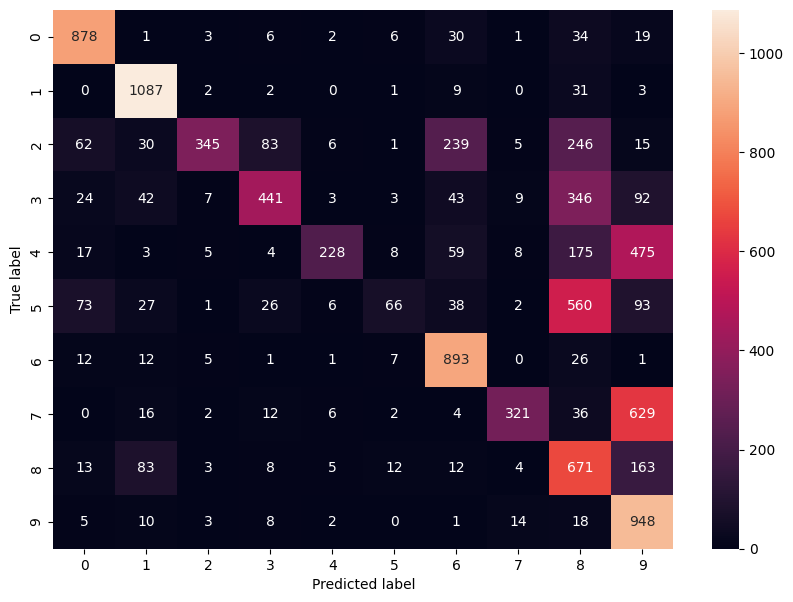

In [ ]:
confusion_matrix(y_test,y_hat_test)

In [26]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255
gnb_scaled = GaussNB()

In [27]:
gnb_scaled.fit(X_train_scaled,y_train)

In [29]:
y_hat_train_scaled = gnb_scaled.predict(X_train_scaled)
y_hat_test_scaled = gnb_scaled.predict(X_test_scaled)

In [30]:
print(accuracy(y_train,y_hat_train_scaled))
print(accuracy(y_test,y_hat_test_scaled))

0.7682333333333333
0.7746


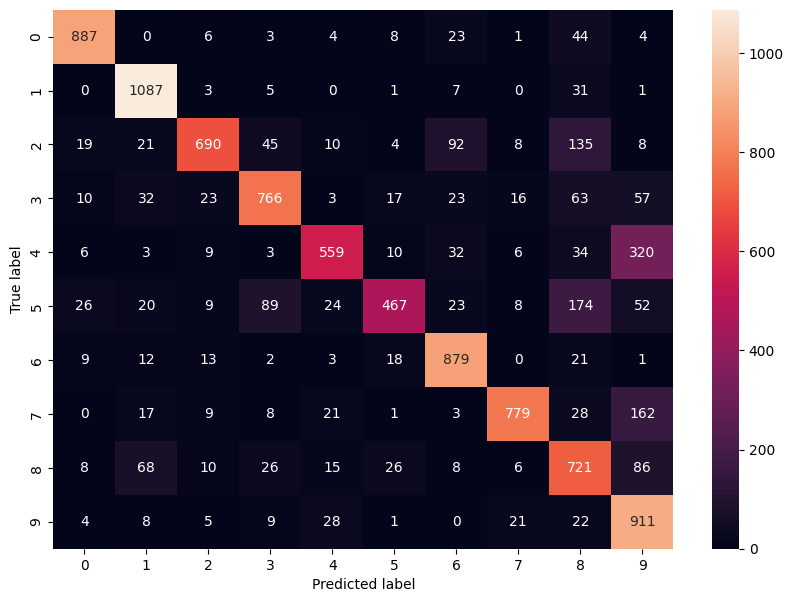

In [ ]:
confusion_matrix(y_test,y_hat_test_scaled)

## Gauss Bayes (Non Naive) Classifier

In [34]:
class GaussBayes():

    def fit(self,X,y,epsilon=1e-3):
        self.likelihood = dict()
        self.priors = dict()

        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k,:]
            N_k, D = X_k.shape
            mu_k = X_k.mean(axis=0)

            self.likelihood[k] = {'mean':X_k.mean(axis=0),
                                  'cov': (1/N_k) * np.matmul((X_k - mu_k).T, (X_k - mu_k)) + epsilon*np.identity(D)}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N,len(self.K)))

        for k, l in self.likelihood.items():
            P_hat[:,k] = mvn.logpdf(X,l['mean'],l['cov'])+np.log(self.priors[k])

        return P_hat.argmax(axis=1)

In [35]:
gaussb = GaussBayes()

In [106]:
gaussb.fit(X_train_scaled,y_train,3.3e-2)
y_hat_test_scaled_gauss = gaussb.predict(X_test_scaled)

In [107]:
print(accuracy(y_test,y_hat_test_scaled_gauss))

0.9564
